# Iris — Our K-means vs Scikit-Learn

Brief questions 3, 4 and 5:
- Apply our own K-means class and Scikit-Learn's K-means to the Iris dataset.
- Run the model several times and for several values of k.
- Evaluate the optimal number of clusters and the quality of the clusters.


In [1]:
import os
import sys

# Make the project root importable so we can load our own kmeans.py
for path in ["..", "."]:
    path = os.path.abspath(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

from kmeans import KMeans  # our from-scratch implementation

print("Setup OK")

Setup OK


## 1. Load and scale the data

In [2]:
iris = load_iris()
X_raw = iris.data
feature_names = iris.feature_names

df = pd.DataFrame(X_raw, columns=feature_names)
print("Shape:", df.shape)
df.head()

Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Standardise: every feature gets mean 0 and standard deviation 1,
# so that no feature dominates the distance calculation.
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Mean of each column after scaling:", np.round(X.mean(axis=0), 3))
print("Std  of each column after scaling:", np.round(X.std(axis=0), 3))

Mean of each column after scaling: [-0. -0. -0. -0.]
Std  of each column after scaling: [1. 1. 1. 1.]


## 2. Our K-means vs Scikit-Learn's K-means (k = 3)

In [4]:
K = 3

ours = KMeans(n_clusters=K, random_state=42)
ours.fit(X)

sk = SklearnKMeans(n_clusters=K, random_state=42, n_init=10)
sk.fit(X)

print("OUR IMPLEMENTATION")
print("  iterations :", ours.n_iter_)
print("  inertia    :", round(ours.inertia_, 4))
print("  sizes      :", np.bincount(ours.labels))
print()
print("SCIKIT-LEARN")
print("  iterations :", sk.n_iter_)
print("  inertia    :", round(sk.inertia_, 4))
print("  sizes      :", np.bincount(sk.labels_))
print()
print("Agreement between the two labelings (Adjusted Rand Index):",
      round(adjusted_rand_score(ours.labels, sk.labels_), 4))

OUR IMPLEMENTATION
  iterations : 7
  inertia    : 140.0328
  sizes      : [56 50 44]

SCIKIT-LEARN
  iterations : 4
  inertia    : 139.8205
  sizes      : [53 50 47]

Agreement between the two labelings (Adjusted Rand Index): 0.9412


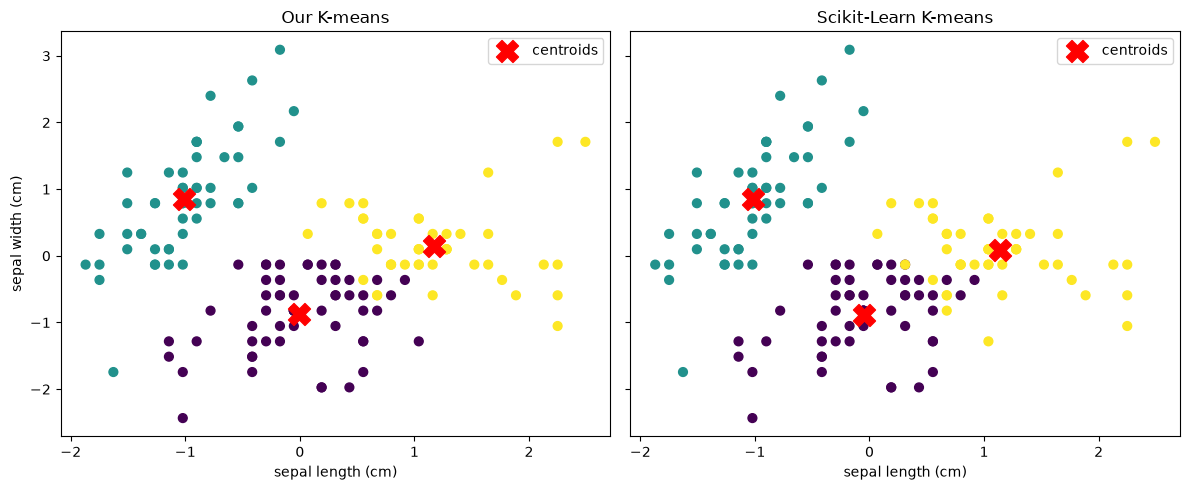

In [5]:
# Visual comparison on the first two features
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], c=ours.labels, cmap="viridis", s=40)
axes[0].scatter(ours.centroids[:, 0], ours.centroids[:, 1],
                c="red", marker="X", s=250, label="centroids")
axes[0].set_title("Our K-means")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c=sk.labels_, cmap="viridis", s=40)
axes[1].scatter(sk.cluster_centers_[:, 0], sk.cluster_centers_[:, 1],
                c="red", marker="X", s=250, label="centroids")
axes[1].set_title("Scikit-Learn K-means")
axes[1].set_xlabel(feature_names[0])
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Running the model several times (brief question 4)

K-means starts from random centroids, so different starting seeds can lead to
different results. Here we run our model with several seeds and compare.

In [6]:
print(f"{'seed':>6} | {'iterations':>10} | {'inertia':>10} | cluster sizes")
print("-" * 55)

for seed in [0, 1, 7, 42, 99, 123, 2024]:
    m = KMeans(n_clusters=3, random_state=seed)
    m.fit(X)
    sizes = np.bincount(m.labels, minlength=3)
    print(f"{seed:>6} | {m.n_iter_:>10} | {m.inertia_:>10.4f} | {sizes}")

  seed | iterations |    inertia | cluster sizes
-------------------------------------------------------
     0 |          6 |   140.9015 | [55 46 49]
     1 |          8 |   140.9015 | [49 46 55]
     7 |          6 |   140.9015 | [55 46 49]
    42 |          7 |   140.0328 | [56 50 44]
    99 |          6 |   140.0328 | [44 50 56]
   123 |          7 |   140.0328 | [50 44 56]
  2024 |          4 |   197.4714 | [ 13  37 100]


## 4. Choosing the optimal k (brief question 5)

- **Elbow method**: plot inertia against k and look for the bend.
- **Silhouette score**: higher is better, so pick the k with the highest score.

In [7]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    m = KMeans(n_clusters=k, random_state=42)
    m.fit(X)
    inertias.append(m.inertia_)
    silhouettes.append(silhouette_score(X, m.labels))

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": np.round(inertias, 4),
    "silhouette": np.round(silhouettes, 4),
})
results

,k,inertia,silhouette
0,2,222.3617,0.5818
1,3,140.0328,0.4630
2,4,114.5568,0.4151
3,5,103.6161,0.3928
4,6,80.8745,0.3365
5,7,72.1701,0.3418
6,8,67.2921,0.3345
7,9,60.0041,0.3527
8,10,57.6510,0.3216


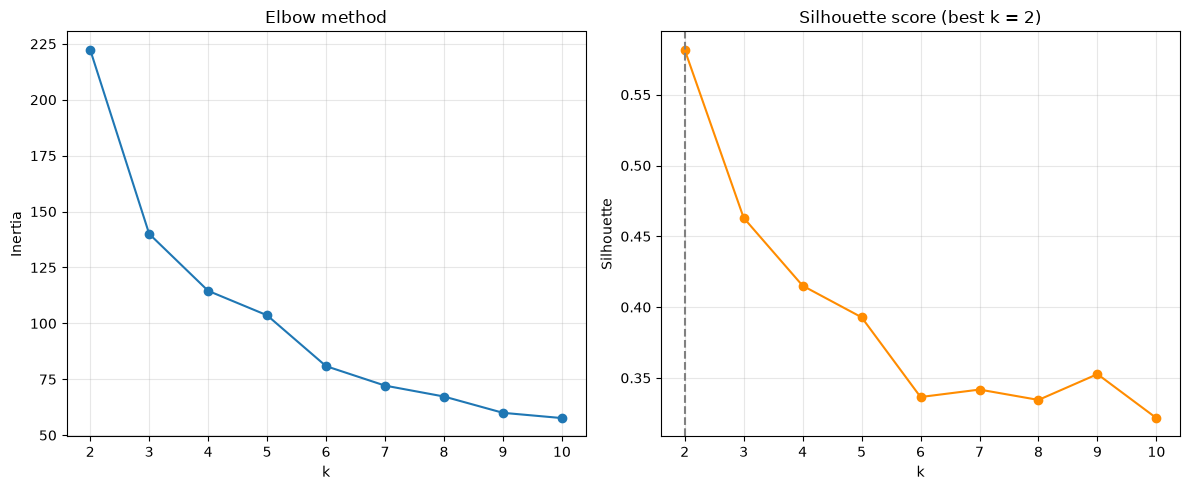

Best k according to the silhouette score: 2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouettes, marker="o", color="darkorange")
best_k = list(k_values)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, linestyle="--", color="grey")
axes[1].set_title(f"Silhouette score (best k = {best_k})")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best k according to the silhouette score:", best_k)

## 5. Conclusion for Iris

- Our from-scratch K-means and Scikit-Learn's K-means produce nearly identical
  clusters (very close inertia, high agreement on the labels), which validates
  our implementation.
- Changing the random seed can change the number of iterations and slightly
  change the result: K-means is sensitive to its initialisation. Scikit-Learn
  handles this by restarting several times (`n_init`) and keeping the best run.
- The elbow appears around k = 2-3, and the silhouette score is highest at the
  value printed above. Iris is known to contain 3 species, but two of them
  overlap, which is why k = 2 often scores well on a purely geometric measure.